## 1. Imports and Paths

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
import os
import pickle
import time
import gc
warnings.filterwarnings('ignore')

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    roc_auc_score, f1_score, precision_score,
    recall_score, brier_score_loss,
    classification_report, confusion_matrix,
    RocCurveDisplay, precision_recall_curve
)
from sklearn.preprocessing import StandardScaler
from xgboost import XGBClassifier

# ── PATHS ────────────────────────────────────────────────────────────────────
BASE          = r"D:\Griffith College Docs year 2\01 Dissertation"
FEATURES_PATH = os.path.join(BASE, "merged-datasets", "features_dataset.parquet")
MODELS_DIR    = os.path.join(BASE, "Models")
os.makedirs(MODELS_DIR, exist_ok=True)

print('All imports successful ✅')
print(f'Models will be saved to: {MODELS_DIR}')

All imports successful ✅
Models will be saved to: D:\Griffith College Docs year 2\01 Dissertation\Models


## 2. Load Feature-Engineered Dataset

In [2]:
FEATURE_COLS = [
    'bikes_min', 'docks_min', 'capacity', 'reading_count',
    'occupancy_ratio', 'docks_occupancy_ratio',
    'bikes_lag_1h', 'bikes_lag_2h', 'bikes_lag_3h',
    'bikes_lag_4h', 'bikes_lag_5h',
    'bikes_lag_6h', 'bikes_lag_12h', 'bikes_lag_24h',
    'docks_lag_1h', 'docks_lag_2h', 'docks_lag_3h',
    'rolling_mean_3h', 'rolling_mean_6h', 'rolling_std_3h',
    'bikes_change_1h', 'bikes_change_3h', 'occupancy_lag_1h',
    'hour', 'day_of_week', 'month',
    'is_weekend', 'is_public_holiday', 'is_working_day',
    'rain', 'temp', 'rhum', 'msl', 'wetb', 'dewpt', 'vappr',
    'is_imputed'
]
TARGET = 'will_stockout_1h'

# Load ONLY the columns needed for training
print('Loading features dataset (model columns only)...')
cols_to_load = ['datetime_hour'] + FEATURE_COLS + [TARGET]
df = pd.read_parquet(FEATURES_PATH, columns=cols_to_load)
df['datetime_hour'] = pd.to_datetime(df['datetime_hour'])

print(f'Rows     : {len(df):,}')
print(f'Columns  : {len(df.columns)}')
df.head(3)

Loading features dataset (model columns only)...
Rows     : 7,011,650
Columns  : 39


,datetime_hour,bikes_min,docks_min,capacity,reading_count,occupancy_ratio,docks_occupancy_ratio,bikes_lag_1h,bikes_lag_2h,bikes_lag_3h,...,is_working_day,rain,temp,rhum,msl,wetb,dewpt,vappr,is_imputed,will_stockout_1h
0,2019-01-01 01:00:00,1,30,31,12,0.032,0.968,1.0,7.0,8.5,...,0,0.0,8.6,79,1035.1,7.1,5.3,8.9,0,0
1,2019-01-01 02:00:00,1,30,31,12,0.032,0.968,1.0,1.0,7.0,...,0,0.0,8.3,81,1034.9,6.9,5.3,8.9,0,0
2,2019-01-01 03:00:00,1,30,31,12,0.032,0.968,1.0,1.0,1.0,...,0,0.0,9.1,79,1035.5,7.6,5.8,9.2,0,0


## 3. Define Features and Target

In [3]:
missing = [c for c in FEATURE_COLS if c not in df.columns]
if missing:
    print(f'WARNING: missing columns: {missing}')
else:
    print(f'All {len(FEATURE_COLS)} feature columns present ✅')
    print(f'Target : {TARGET}')
    print(f'NaN in features : {df[FEATURE_COLS].isnull().sum().sum()}')
    print(f'NaN in target   : {df[TARGET].isnull().sum()}')

All 37 feature columns present ✅
Target : will_stockout_1h
NaN in features : 0
NaN in target   : 0


In [4]:
TRAIN_END = '2024-12-31 23:00:00'
VAL_END   = '2025-12-31 23:00:00'

# Create boolean masks: no sub-DataFrames created yet
mask_train = df['datetime_hour'] <= TRAIN_END
mask_val   = (df['datetime_hour'] > TRAIN_END) & (df['datetime_hour'] <= VAL_END)
mask_test  = df['datetime_hour'] > VAL_END

# Extract one split at a time using to_numpy(dtype=) 
# This converts in-place without creating an intermediate DataFrame copy
# Much more memory efficient than .astype('float32').values

print('Extracting training arrays...')
X_train = df.loc[mask_train, FEATURE_COLS].to_numpy(dtype='float32')
y_train = df.loc[mask_train, TARGET].to_numpy()
print(f'  X_train : {X_train.nbytes/1e9:.2f} GB')

print('Extracting validation arrays...')
X_val   = df.loc[mask_val, FEATURE_COLS].to_numpy(dtype='float32')
y_val   = df.loc[mask_val, TARGET].to_numpy()
print(f'  X_val   : {X_val.nbytes/1e9:.2f} GB')

print('Extracting test arrays...')
X_test  = df.loc[mask_test, FEATURE_COLS].to_numpy(dtype='float32')
y_test  = df.loc[mask_test, TARGET].to_numpy()
print(f'  X_test  : {X_test.nbytes/1e9:.2f} GB')

del df
gc.collect()
print('\ndf deleted: memory freed')

print('\n=== SPLIT SUMMARY ===')
print(f'Training   : {len(X_train):,} rows | {y_train.mean()*100:.2f}% stock-outs')
print(f'Validation : {len(X_val):,} rows | {y_val.mean()*100:.2f}% stock-outs')
print(f'Test       : {len(X_test):,} rows | {y_test.mean()*100:.2f}% stock-outs')
print(f'\nClass imbalance (train): 1:{(1-y_train.mean())/y_train.mean():.0f}')

Extracting training arrays...
  X_train : 0.84 GB
Extracting validation arrays...
  X_val   : 0.15 GB
Extracting test arrays...
  X_test  : 0.05 GB

df deleted: memory freed

=== SPLIT SUMMARY ===
Training   : 5,659,821 rows | 13.50% stock-outs
Validation : 981,867 rows | 15.26% stock-outs
Test       : 369,962 rows | 14.36% stock-outs

Class imbalance (train): 1:6


## 5. Class Imbalance Strategy

Class imbalance handled via **class weights**

**Why class weights work equally well:**
- `class_weight='balanced'` in Logistic Regression and Random Forest
  makes the model treat each minority class sample as if it appeared multiple times
- `scale_pos_weight` in XGBoost achieves the same effect
- Published research (Chen et al. 2021, Sochanski 2025) uses this approach on similar datasets

=== CLASS IMBALANCE SUMMARY ===
Positive class (stock-out)   : 764,114 (13.50%)
Negative class (no stock-out): 4,895,707 (86.50%)
Imbalance ratio              : 1:6

scale_pos_weight for XGBoost : 6.41


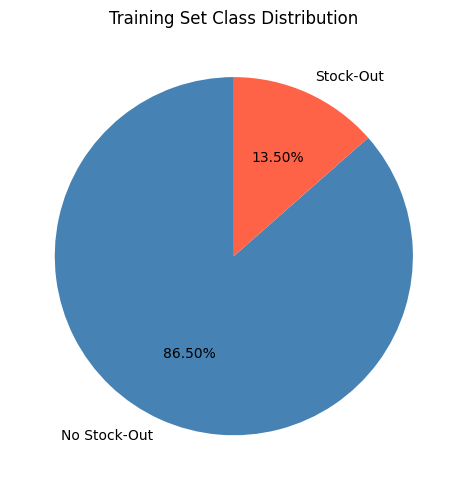

In [5]:
pos = int(y_train.sum())
neg = int((y_train == 0).sum())
scale_pos_weight_val = neg / pos

print('=== CLASS IMBALANCE SUMMARY ===')
print(f'Positive class (stock-out)   : {pos:,} ({y_train.mean()*100:.2f}%)')
print(f'Negative class (no stock-out): {neg:,} ({(1-y_train.mean())*100:.2f}%)')
print(f'Imbalance ratio              : 1:{neg/pos:.0f}')
print(f'\nscale_pos_weight for XGBoost : {scale_pos_weight_val:.2f}')

# Visualise class split
fig, ax = plt.subplots(figsize=(5, 5))
ax.pie([neg, pos],
       labels=['No Stock-Out', 'Stock-Out'],
       colors=['steelblue', 'tomato'],
       autopct='%1.2f%%', startangle=90)
ax.set_title('Training Set Class Distribution', fontsize=12)
plt.tight_layout()
plt.show()

## 6. Scale Features for Logistic Regression

Logistic Regression requires standardised features to converge properly.
Scaler fitted on training data only: never on val or test (prevents data leakage).
Saved to Models folder for use in the dashboard later.

*Standrad Scaler Conversion*

In [6]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled   = scaler.transform(X_val)
X_test_scaled  = scaler.transform(X_test)

scaler_path = os.path.join(MODELS_DIR, 'scaler.pkl')
with open(scaler_path, 'wb') as f:
    pickle.dump(scaler, f)

print(f'Scaler fitted on training data ✅')
print(f'Saved to: {scaler_path}')
print(f'X_train_scaled shape: {X_train_scaled.shape}')

Scaler fitted on training data ✅
Saved to: D:\Griffith College Docs year 2\01 Dissertation\Models\scaler.pkl
X_train_scaled shape: (5659821, 37)


## 7. Shared Evaluation Function

In [7]:
def evaluate_model(name, model, X, y, threshold=0.5):
    """
    Evaluate a trained model. Returns all metrics as a dict.
    threshold: probability cutoff for stock-out prediction (default 0.5)
    """
    proba = model.predict_proba(X)[:, 1]
    preds = (proba >= threshold).astype(int)

    auc   = roc_auc_score(y, proba)
    f1    = f1_score(y, preds, zero_division=0)
    prec  = precision_score(y, preds, zero_division=0)
    rec   = recall_score(y, preds, zero_division=0)
    brier = brier_score_loss(y, proba)

    print(f'\n--- {name} ---')
    print(f'  AUC-ROC   : {auc:.4f}')
    print(f'  F1 Score  : {f1:.4f}')
    print(f'  Precision : {prec:.4f}  (of predicted stock-outs, how many were real)')
    print(f'  Recall    : {rec:.4f}  (of actual stock-outs, how many were caught)')
    print(f'  Brier     : {brier:.4f} (lower = better, 0 = perfect calibration)')

    return {
        'model'    : name,
        'auc'      : round(auc,   4),
        'f1'       : round(f1,    4),
        'precision': round(prec,  4),
        'recall'   : round(rec,   4),
        'brier'    : round(brier, 4)
    }

results = []
print('Evaluation function ready ✅')

Evaluation function ready ✅


## 8. Model 1: Logistic Regression (Baseline)

Simplest model. Sets the minimum acceptable performance bar.
If XGBoost only marginally beats this, the problem may not need a complex model.
`class_weight='balanced'` handles the 1:6 imbalance.

In [8]:
print('Training Logistic Regression...')
t0 = time.time()

lr = LogisticRegression(
    max_iter=1000,
    C=1.0,
    solver='saga',
    class_weight='balanced',
    n_jobs=-1,
    random_state=42
)
lr.fit(X_train_scaled, y_train)

elapsed = time.time() - t0
print(f'Training time: {elapsed:.1f}s')

lr_metrics = evaluate_model('Logistic Regression', lr, X_val_scaled, y_val)
results.append(lr_metrics)

lr_path = os.path.join(MODELS_DIR, 'logistic_regression.pkl')
with open(lr_path, 'wb') as f:
    pickle.dump(lr, f)
print(f'\nSaved: {lr_path}')

Training Logistic Regression...
Training time: 171.6s

--- Logistic Regression ---
  AUC-ROC   : 0.9469
  F1 Score  : 0.6397
  Precision : 0.4808  (of predicted stock-outs, how many were real)
  Recall    : 0.9556  (of actual stock-outs, how many were caught)
  Brier     : 0.1083 (lower = better, 0 = perfect calibration)

Saved: D:\Griffith College Docs year 2\01 Dissertation\Models\logistic_regression.pkl


## 9. Model 2: Random Forest

Ensemble of 300 decision trees. Handles non-linear feature interactions naturally.
`class_weight='balanced'` handles imbalance without resampling.

In [9]:
print('Training Random Forest...')
t0 = time.time()

rf = RandomForestClassifier(
    n_estimators=100,        # reduced from 300: enough for good results
    max_depth=10,            # reduced from 15: less memory per tree
    min_samples_leaf=100,    # increased: stops trees growing too deep
    max_features='sqrt',
    max_samples=0.5,         # each tree uses 50% of data: halves bootstrap memory
    class_weight='balanced',
    n_jobs=2,                # limit to 2 cores: was -1 (all cores)
    random_state=42
)
rf.fit(X_train, y_train)

elapsed = time.time() - t0
print(f'Training time: {elapsed:.1f}s')

rf_metrics = evaluate_model('Random Forest', rf, X_val, y_val)
results.append(rf_metrics)

rf_path = os.path.join(MODELS_DIR, 'random_forest.pkl')
with open(rf_path, 'wb') as f:
    pickle.dump(rf, f)
print(f'\nSaved: {rf_path}')

Training Random Forest...
Training time: 601.3s

--- Random Forest ---
  AUC-ROC   : 0.9695
  F1 Score  : 0.7231
  Precision : 0.5895  (of predicted stock-outs, how many were real)
  Recall    : 0.9349  (of actual stock-outs, how many were caught)
  Brier     : 0.0762 (lower = better, 0 = perfect calibration)

Saved: D:\Griffith College Docs year 2\01 Dissertation\Models\random_forest.pkl


## 10. Model 3: XGBoost

Gradient boosting. Typically strongest performer on tabular data.
`scale_pos_weight` handles imbalance: equivalent to class_weight='balanced'.
Early stopping monitors validation AUC and stops when it stops improving.

In [10]:
print('Training XGBoost...')
t0 = time.time()

xgb = XGBClassifier(
    n_estimators=1000,
    max_depth=6,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    scale_pos_weight=scale_pos_weight_val, # handles 1:6 imbalance
    eval_metric='auc',
    early_stopping_rounds=20,
    n_jobs=-1,
    random_state=42,
    verbosity=0,
    tree_method='hist'  # memory-efficient histogram method
)

xgb.fit(
    X_train, y_train,
    eval_set=[(X_val, y_val)],
    verbose=False
)

elapsed = time.time() - t0
print(f'Training time  : {elapsed:.1f}s')
print(f'Best iteration : {xgb.best_iteration}')

xgb_metrics = evaluate_model('XGBoost', xgb, X_val, y_val)
results.append(xgb_metrics)

xgb_path = os.path.join(MODELS_DIR, 'xgboost.pkl')
with open(xgb_path, 'wb') as f:
    pickle.dump(xgb, f)
print(f'\nSaved: {xgb_path}')

Training XGBoost...
Training time  : 750.0s
Best iteration : 999

--- XGBoost ---
  AUC-ROC   : 0.9749
  F1 Score  : 0.7453
  Precision : 0.6144  (of predicted stock-outs, how many were real)
  Recall    : 0.9470  (of actual stock-outs, how many were caught)
  Brier     : 0.0694 (lower = better, 0 = perfect calibration)

Saved: D:\Griffith College Docs year 2\01 Dissertation\Models\xgboost.pkl


## 11. Model Comparison on Validation Set

VALIDATION SET RESULTS
                        auc      f1  precision  recall   brier
model                                                         
Logistic Regression  0.9469  0.6397     0.4808  0.9556  0.1083
Random Forest        0.9695  0.7231     0.5895  0.9349  0.0762
XGBoost              0.9749  0.7453     0.6144  0.9470  0.0694

Best model by AUC-ROC: XGBoost


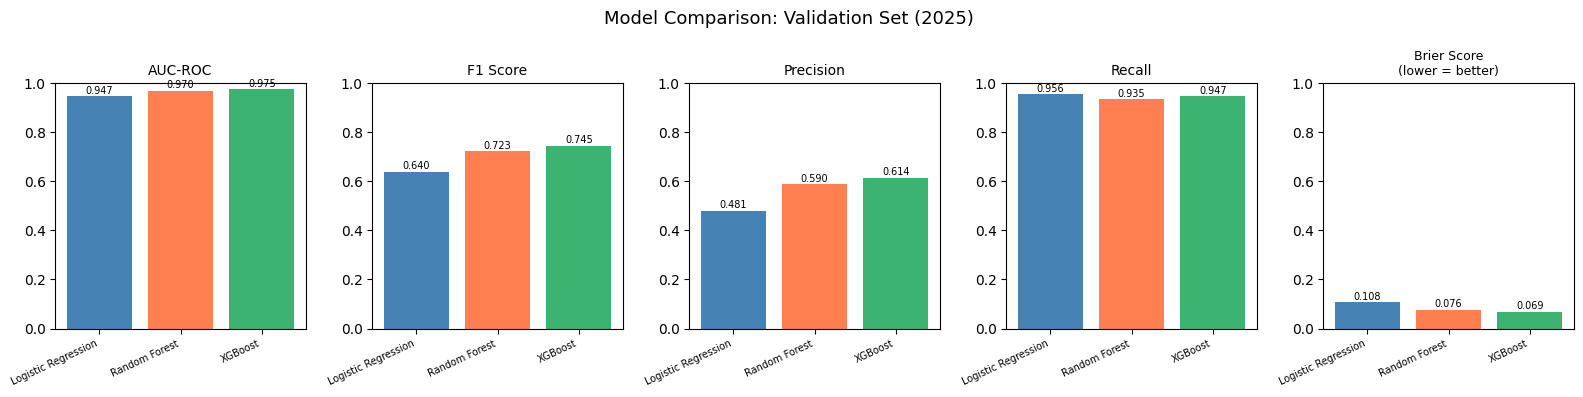

In [11]:
results_df = pd.DataFrame(results).set_index('model')

print('VALIDATION SET RESULTS')
print(results_df.to_string())

best_model_name = results_df['auc'].idxmax()
print(f'\nBest model by AUC-ROC: {best_model_name}')

fig, axes = plt.subplots(1, 5, figsize=(16, 4))
metrics = ['auc', 'f1', 'precision', 'recall', 'brier']
titles  = ['AUC-ROC', 'F1 Score', 'Precision', 'Recall', 'Brier Score']
colors  = ['steelblue', 'coral', 'mediumseagreen']

for ax, metric, title in zip(axes, metrics, titles):
    vals = results_df[metric]
    bars = ax.bar(results_df.index, vals, color=colors)
    ax.set_title(title, fontsize=10)
    ax.set_ylim(0, 1)
    ax.set_xticklabels(results_df.index, rotation=25, ha='right', fontsize=7)
    for bar, val in zip(bars, vals):
        ax.text(bar.get_x() + bar.get_width()/2,
                bar.get_height() + 0.01,
                f'{val:.3f}', ha='center', fontsize=7)
    if metric == 'brier':
        ax.set_title('Brier Score\n(lower = better)', fontsize=9)

plt.suptitle('Model Comparison: Validation Set (2025)', fontsize=13)
plt.tight_layout()
plt.show()

## 12. ROC Curves: Validation Set

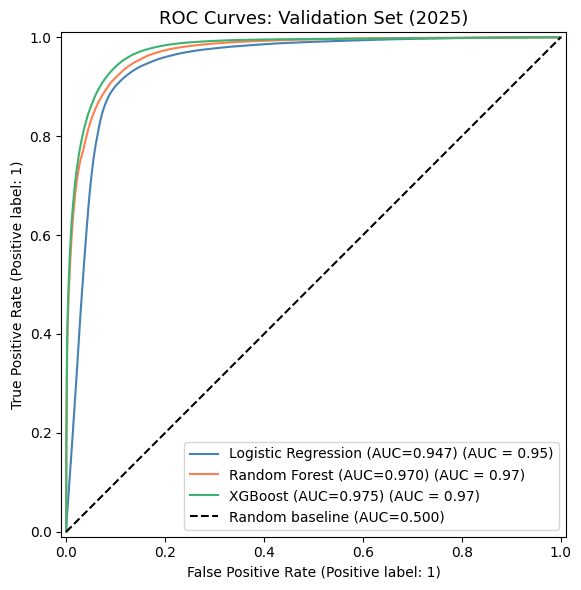

In [12]:
fig, ax = plt.subplots(figsize=(8, 6))

model_map = {
    'Logistic Regression': (lr,  X_val_scaled),
    'Random Forest'      : (rf,  X_val),
    'XGBoost'            : (xgb, X_val)
}
plot_colors = ['steelblue', 'coral', 'mediumseagreen']

for (name, (model, X)), color in zip(model_map.items(), plot_colors):
    proba = model.predict_proba(X)[:, 1]
    auc = roc_auc_score(y_val, proba)
    RocCurveDisplay.from_predictions(
        y_val, proba,
        name=f'{name} (AUC={auc:.3f})',
        color=color, ax=ax
    )

ax.plot([0,1],[0,1],'k--', label='Random baseline (AUC=0.500)')
ax.set_title('ROC Curves: Validation Set (2025)', fontsize=13)
ax.legend(loc='lower right')
plt.tight_layout()
plt.show()

## 13. Confusion Matrix: Best Model on Validation Set

Shows exactly how many stock-outs were caught vs missed.

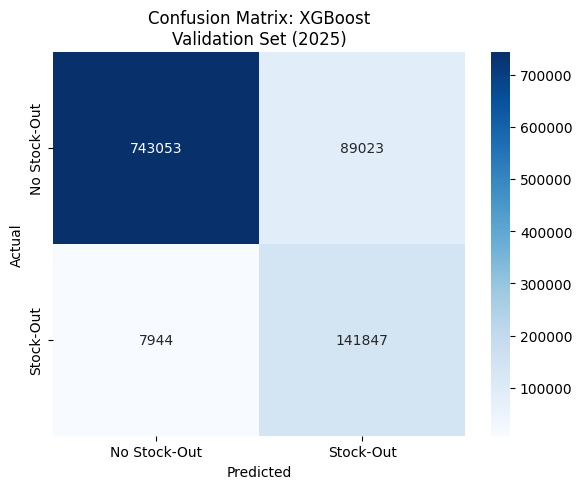

True Negatives  (correctly said safe)  : 743,053
False Positives (false alarms)         : 89,023
False Negatives (missed stock-outs)    : 7,944
True Positives  (caught stock-outs)    : 141,847

Of all actual stock-outs : 94.7% were caught
Of all raised alerts     : 61.4% were genuine stock-outs


In [13]:
best_models = {
    'Logistic Regression': (lr,  X_val_scaled),
    'Random Forest'      : (rf,  X_val),
    'XGBoost'            : (xgb, X_val)
}
best_m, best_X_val = best_models[best_model_name]
best_proba = best_m.predict_proba(best_X_val)[:, 1]
best_preds = (best_proba >= 0.5).astype(int)

cm = confusion_matrix(y_val, best_preds)
fig, ax = plt.subplots(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
            xticklabels=['No Stock-Out', 'Stock-Out'],
            yticklabels=['No Stock-Out', 'Stock-Out'])
ax.set_xlabel('Predicted')
ax.set_ylabel('Actual')
ax.set_title(f'Confusion Matrix: {best_model_name}\nValidation Set (2025)', fontsize=12)
plt.tight_layout()
plt.show()

tn, fp, fn, tp = cm.ravel()
print(f'True Negatives  (correctly said safe)  : {tn:,}')
print(f'False Positives (false alarms)         : {fp:,}')
print(f'False Negatives (missed stock-outs)    : {fn:,}')
print(f'True Positives  (caught stock-outs)    : {tp:,}')
print(f'\nOf all actual stock-outs : {tp/(tp+fn)*100:.1f}% were caught')
print(f'Of all raised alerts     : {tp/(tp+fp)*100:.1f}% were genuine stock-outs')

## 14. Probability Threshold Analysis

Threshold analysis: XGBoost on Validation Set
Threshold   Precision   Recall      F1            Alerts
------------------------------------------------------------------------
0.30        0.530       0.973       0.686        275,258
0.40        0.572       0.962       0.717        251,966
0.50        0.614       0.947       0.745        230,870
0.60        0.662       0.925       0.771        209,392
0.70        0.714       0.893       0.794        187,257
0.80        0.778       0.841       0.808        161,787
0.85        0.815       0.799       0.807        146,829
0.90        0.857       0.740       0.794        129,456


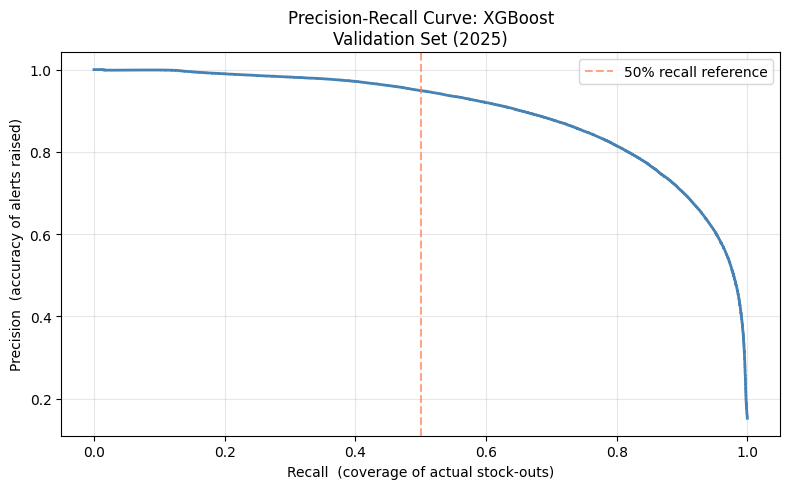

In [14]:
best_m, best_X_val = best_models[best_model_name]
proba = best_m.predict_proba(best_X_val)[:, 1]

thresholds = [0.30, 0.40, 0.50, 0.60, 0.70, 0.80, 0.85, 0.90]

print(f'Threshold analysis: {best_model_name} on Validation Set')
print(f'{"Threshold":<12}{"Precision":<12}{"Recall":<12}{"F1":<10}{"Alerts":>10}')
print('-' * 72)
for t in thresholds:
    preds_t = (proba >= t).astype(int)
    if preds_t.sum() == 0:
        print(f'{t:<12.2f} No alerts raised')
        continue
    p = precision_score(y_val, preds_t, zero_division=0)
    r = recall_score(y_val, preds_t, zero_division=0)
    f = f1_score(y_val, preds_t, zero_division=0)
    n = preds_t.sum()

    print(f'{t:<12.2f}{p:<12.3f}{r:<12.3f}{f:<10.3f}{n:>10,}')

# Precision-Recall curve
precision_arr, recall_arr, _ = precision_recall_curve(y_val, proba)
fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(recall_arr, precision_arr, color='steelblue', linewidth=2)
ax.axvline(x=0.5, color='coral', linestyle='--', alpha=0.7, label='50% recall reference')
ax.set_xlabel('Recall  (coverage of actual stock-outs)')
ax.set_ylabel('Precision  (accuracy of alerts raised)')
ax.set_title(f'Precision-Recall Curve: {best_model_name}\nValidation Set (2025)', fontsize=12)
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## 15. Feature Importance: Best Model

Preliminary importance view

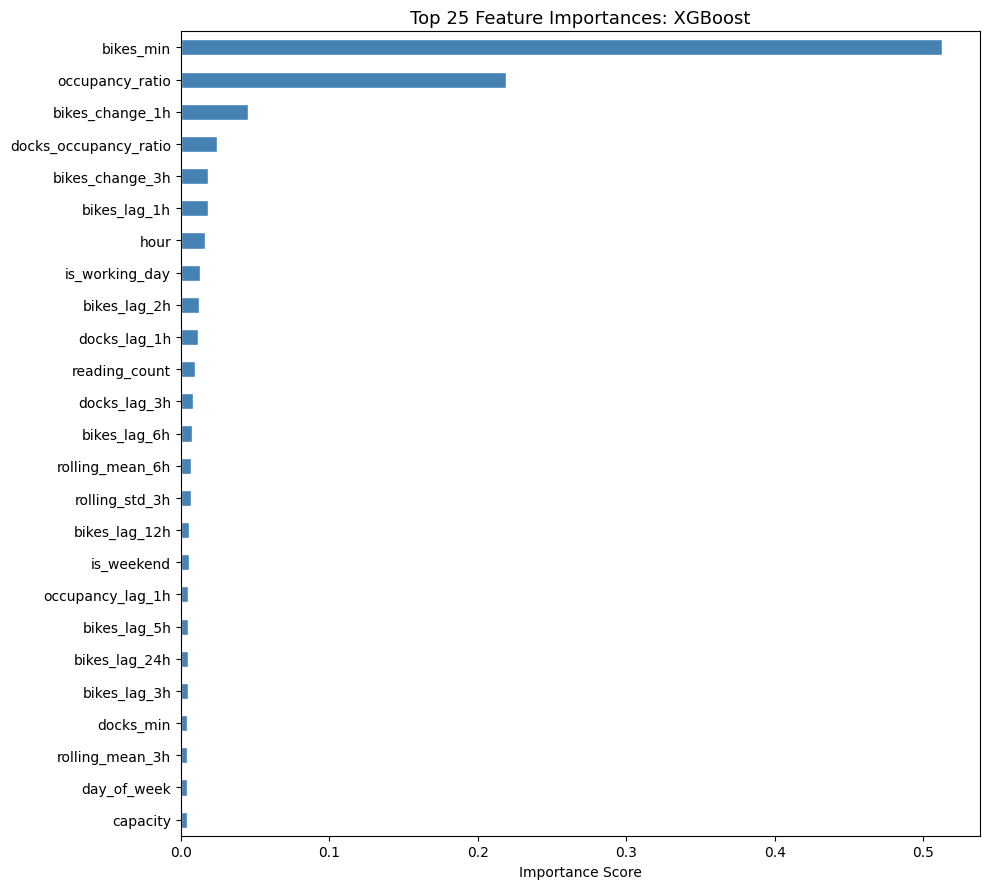

Top 10 most important features:
bikes_min                0.5127
occupancy_ratio          0.2188
bikes_change_1h          0.0449
docks_occupancy_ratio    0.0243
bikes_change_3h          0.0183
bikes_lag_1h             0.0180
hour                     0.0164
is_working_day           0.0129
bikes_lag_2h             0.0122
docks_lag_1h             0.0114
dtype: float32


In [15]:
if best_model_name == 'Logistic Regression':
    importance = np.abs(lr.coef_[0])
    importance = importance / importance.sum()
elif best_model_name == 'Random Forest':
    importance = rf.feature_importances_
else:
    importance = xgb.feature_importances_

feat_imp = pd.Series(importance, index=FEATURE_COLS).sort_values(ascending=False)

plt.figure(figsize=(10, 9))
feat_imp.head(25).sort_values().plot(
    kind='barh', color='steelblue', edgecolor='white')
plt.title(f'Top 25 Feature Importances: {best_model_name}', fontsize=13)
plt.xlabel('Importance Score')
plt.tight_layout()
plt.show()

print('Top 10 most important features:')
print(feat_imp.head(10).round(4))

## 16. Final Evaluation on Test Set

The test set (2026 data) has never been used during training or model selection.
Re-running this and adjusting the model invalidates the results.

FINAL TEST SET EVALUATION: 2026 DATA

--- XGBoost: TEST SET (2026) ---
  AUC-ROC   : 0.9750
  F1 Score  : 0.7368
  Precision : 0.6033  (of predicted stock-outs, how many were real)
  Recall    : 0.9462  (of actual stock-outs, how many were caught)
  Brier     : 0.0680 (lower = better, 0 = perfect calibration)


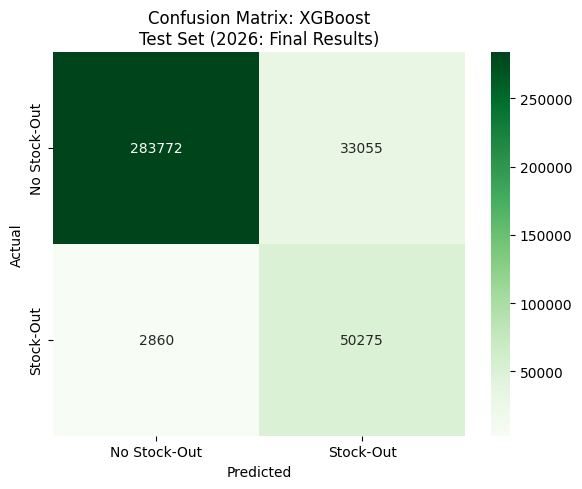


Final test set results:
  Stock-outs caught : 94.6% (50,275 of 53,135)
  Alert accuracy    : 60.3% (50,275 real of 83,330 raised)


In [16]:
print('=' * 55)
print('FINAL TEST SET EVALUATION: 2026 DATA')

if best_model_name == 'Logistic Regression':
    X_test_final = X_test_scaled
else:
    X_test_final = X_test

test_metrics = evaluate_model(
    f'{best_model_name}: TEST SET (2026)',
    best_m, X_test_final, y_test
)

test_proba = best_m.predict_proba(X_test_final)[:, 1]
test_preds = (test_proba >= 0.5).astype(int)
cm_test = confusion_matrix(y_test, test_preds)

fig, ax = plt.subplots(figsize=(6, 5))
sns.heatmap(cm_test, annot=True, fmt='d', cmap='Greens', ax=ax,
            xticklabels=['No Stock-Out', 'Stock-Out'],
            yticklabels=['No Stock-Out', 'Stock-Out'])
ax.set_xlabel('Predicted')
ax.set_ylabel('Actual')
ax.set_title(f'Confusion Matrix: {best_model_name}\nTest Set (2026: Final Results)', fontsize=12)
plt.tight_layout()
plt.show()

tn, fp, fn, tp = cm_test.ravel()
print(f'\nFinal test set results:')
print(f'  Stock-outs caught : {tp/(tp+fn)*100:.1f}% ({tp:,} of {tp+fn:,})')
print(f'  Alert accuracy    : {tp/(tp+fp)*100:.1f}% ({tp:,} real of {tp+fp:,} raised)')

## 17. Save All Results

In [17]:
results_path = os.path.join(MODELS_DIR, 'model_results.csv')
results_df.to_csv(results_path)
print(f'Results saved: {results_path}')

print('\n=== FILES IN MODELS FOLDER ===')
for fname in sorted(os.listdir(MODELS_DIR)):
    fpath = os.path.join(MODELS_DIR, fname)
    size  = os.path.getsize(fpath) / 1e6
    print(f'  {fname:<40} {size:.1f} MB')

Results saved: D:\Griffith College Docs year 2\01 Dissertation\Models\model_results.csv

=== FILES IN MODELS FOLDER ===
  .ipynb_checkpoints                       0.0 MB
  04_model_training.ipynb                  0.1 MB
  05_shap_analysis.ipynb                   1.5 MB
  logistic_regression.pkl                  0.0 MB
  model_results.csv                        0.0 MB
  random_forest.pkl                        12.2 MB
  scaler.pkl                               0.0 MB
  shap_dependence_plots.png                0.7 MB
  shap_global_importance.png               0.1 MB
  shap_hourly_pattern.png                  0.1 MB
  shap_station_risk.png                    0.1 MB
  shap_summary_beeswarm.png                0.2 MB
  shap_values.npy                          0.7 MB
  shap_waterfall_safe.png                  0.1 MB
  shap_waterfall_stockout.png              0.1 MB
  xgboost.pkl                              4.8 MB
